In [1]:
import sys
import platform
from os.path import join, exists, abspath, dirname
from os import getcwd, makedirs, remove
from glob import glob

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps, cm
from matplotlib import colors as mcolors
import scipy
from scipy.stats import kendalltau
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from scipy.io import loadmat
from sklearn.metrics import r2_score
from statsmodels.stats.anova import AnovaRM
import seaborn as sns

from tqdm import tqdm

In [2]:
import nibabel as nb
from nilearn import plotting, image
from nipype.interfaces import fsl

In [3]:
from nilearn.mass_univariate import permuted_ols

In [4]:
dir_current = getcwd().replace('\\','/')

tmp = dir_current.split('/')
idx = [ii for ii, s in enumerate(tmp) if s=='github'][0]

dir_git = '/'.join(tmp[:idx+1])
dir_git

'/home/sungbeenpark/github'

In [5]:
dname = join(dir_git,'nitools')
sys.path.append(dname)
import nitools as nt

In [6]:
dname = join(dir_git,'SUITPy')
sys.path.append(dname)
import SUITPy as suit

In [7]:
dname = join(dir_git)
sys.path.append(dname)
import surfAnalysisPy as surf

In [8]:
dname = join(dir_git,'Functional_Fusion')
sys.path.append(dname)
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

In [9]:
dname = join(dir_git,'AnatSearchlight')
sys.path.append(dname)
import AnatSearchlight.searchlight as sl

In [10]:
dname = abspath(join(dir_git,'PcmPy'))
sys.path.append(dname)
import PcmPy as pcm

In [11]:
dname = join(dir_git,'SeqSpatialSupp_fMRI')
sys.path.append(dname)
from SSS import deal_spm
from SSS import util as su
from SSS import stat as sstat
from SSS import plot as splt
from SSS import image as simage
from SSS import glmsingle as ssingle
from SSS import correction as scorrect

---

In [12]:
hem = 'L'

In [13]:
list_sn = su.get_list_sn()

---

In [14]:
dir_surf = join(ssingle.get_dir_glmsingle(),'surfaceWB')
dir_surf

'/mnt/f/SeqSpatialSupp_fMRI/GLMsingle/surfaceWB'

In [15]:
dir_group = join(dir_surf,'group')

In [25]:
glm = 2
dir_work = join(dir_surf,'glm_%1d'%glm)
dir_work

'/mnt/f/SeqSpatialSupp_fMRI/GLMsingle/surfaceWB/glm_2'

---

In [20]:
thresh = sstat.convert_alpha_to_tval(alpha=0.05, df=len(list_sn)-1, alternative='greater')
thresh

np.float64(2.200985160082949)

---

### surface adjacency matrix

In [18]:
fname = join(dir_git,'fs_LR_32/fs_LR.32k.L.midthickness.surf.gii')
exists(fname)

True

In [19]:
adj = scorrect.get_adjacenct_matrix_fs32k(fname)

---

In [27]:
border, brdr = simage.get_border(dir_git=dir_git, atlas='sulcus')

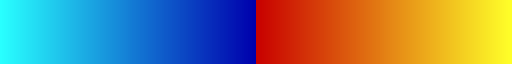

In [22]:
cblue = splt.cmap_i2f(ini='#29FFFF', fin='#0000AD')
cred = splt.cmap_i2f(ini='#C90000', fin='#FFFF29')
cmap = splt.cmap_combine(cblue,cred)
cmap

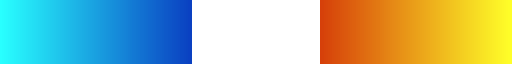

In [23]:
vmax = 0.2
ttt = 0.05
cscale=[-vmax,vmax]
cmap = splt.cmap_norm(cmap=cmap, vmax=vmax, thresh=ttt, alpha=0)
cmap

In [24]:
def get_data(cond, thresh=None):
    fname = join(dir_group,'smooth.cifti.%s.glm_%1d.t_stat.%s.dscalar.nii'%(hem,glm,cond))
    
    data = np.array(nb.load(fname).get_fdata())
    ## percent signal change
    psc = np.copy(data[0])
    ## t-map
    tmap = np.copy(data[1])

    if not thresh == None:
        ## thresholding
        idx = np.copy(abs(tmap)>thresh)
        psc[~idx] = np.nan
    
    return psc, tmap

### within Cue

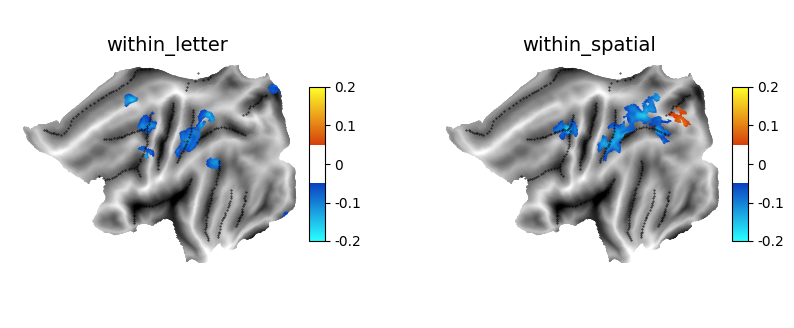

In [30]:
fig, axs = plt.subplots(ncols=2, figsize=(10,4))

for ii, cond in enumerate(['within_letter','within_spatial']):
    ax=axs[ii]
    plt.sca(ax)
    
    psc, tmap = get_data(cond=cond, thresh=thresh)
    psc[np.abs(psc)<ttt] = np.nan
    clusters = scorrect.find_clusters(
        supra=abs(tmap)>thresh,
        adj=adj
    )
    mask = scorrect.make_cluster_corrected_mask(tmap=tmap, clusters=clusters, N=60)
    
    color = 'black'
    g = surf.plot.plotmap(
        data=psc*mask,
        surf='fs32k_%s'%hem,
        alpha=1,
        cmap=cmap, colorbar=True,
        cscale=cscale,
        # threshold=[-thresh,thresh],
        borders=border, bordercolor=color, bordersize=0.75,
        overlay_type='func', render='matplotlib',
    )
    g.text(x=20, y=220, s=cond, ha='center', va='center', fontsize=14)
    # for line, (x, y) in brdr.items():
    #     g.text(x=x, y=y, s=line, ha='left', va='bottom', color=color, fontsize=9)

In [31]:
fig.savefig(
    join(su.get_dir_root(),'within.corrected.png'),
    dpi=300, facecolor=[1,1,1,1], bbox_inches = "tight"
)

### between Cue

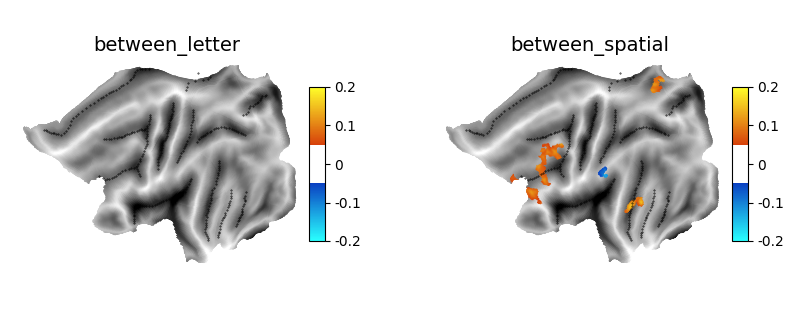

In [32]:
fig, axs = plt.subplots(ncols=2, figsize=(10,4))

for ii, cond in enumerate(['between_letter','between_spatial']):
    ax=axs[ii]
    plt.sca(ax)
    
    psc, tmap = get_data(cond=cond, thresh=thresh)
    psc[np.abs(psc)<ttt] = np.nan
    clusters = scorrect.find_clusters(
        supra=abs(tmap)>thresh,
        adj=adj
    )
    mask = scorrect.make_cluster_corrected_mask(tmap=tmap, clusters=clusters, N=60)
    
    color = 'black'
    g = surf.plot.plotmap(
        data=psc*mask,
        surf='fs32k_%s'%hem,
        alpha=1,
        cmap=cmap, colorbar=True,
        cscale=cscale,
        # threshold=[-thresh,thresh],
        borders=border, bordercolor=color, bordersize=0.75,
        overlay_type='func', render='matplotlib',
    )
    g.text(x=20, y=220, s=cond, ha='center', va='center', fontsize=14)
    # for line, (x, y) in brdr.items():
    #     g.text(x=x, y=y, s=line, ha='left', va='bottom', color=color, fontsize=9)

In [34]:
fig.savefig(
    join(su.get_dir_root(),'between.corrected.png'),
    dpi=300, facecolor=[1,1,1,1], bbox_inches = "tight"
)

---